# Model Training and Comparison

This notebook tests different models for predicting glacier mass balance using the climate features selected in Notebook 2. The models are compared using MAE, RMSE, and R² to see which one performs best before moving on to future predictions.

In [70]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score


## Load Historical Data

Load the processed historical data from Notebook 1 and check that the data looks correct before using it for model training.

In [71]:
DATA_DIR = Path("..") / "data"
PROCESSED_DIR = DATA_DIR / "processed"

data_file = PROCESSED_DIR / "MontBlanc_Historical_Model_Data_1968-2015.csv"

data = pd.read_csv(data_file)

print("Shape:", data.shape)
print("Years:", data["hydrological_year"].min(), "-", data["hydrological_year"].max())
print("Glacier Records:", data["glacier_index"].nunique())
print("Missing values:", data.isna().sum().sum())

data.head()

Shape: (2724, 14)
Years: 1968 - 2015
Glacier Records: 58
Missing values: 0


,hydrological_year,glacier_index,annual_temperature_c,winter_temperature_c,summer_temperature_c,annual_precipitation_mm,winter_precipitation_mm,summer_precipitation_mm,RGI_ID,GLIMS_ID,glacier_name,latitude,longitude,mass_balance
0,1968,423,1.040538,-4.237914,6.318990,1622.972595,787.011292,835.961303,3344,G006776E45799N,de la Berangere,45.799,6.776,1.020175
1,1968,424,1.064644,-4.219128,6.348415,1633.635529,790.549427,843.086102,3601,G006778E45809N,d'Armancette,45.809,6.778,0.992590
2,1968,427,1.069756,-4.218176,6.357689,1638.001434,791.076965,846.924469,3650,G006783E45817N,de Covagnet,45.817,6.783,1.047586
3,1968,429,0.959309,-4.310709,6.229326,1593.901842,774.321153,819.580689,3651,G006784E45784N,de Tre la Tete 1,45.784,6.784,-0.154915
4,1968,431,1.077550,-4.213031,6.368132,1642.061705,792.160762,849.900943,3276,G006785E45822N,du Miage 1,45.822,6.785,-0.445979


## Training and Test Data

The data was split by year instead of randomly since the goal is to eventually predict future glacier mass balance. The years 1968–2005 are used for training and the last 10 years, 2006–2015, are saved for testing. This gives the model several years of data to learn from while still leaving a later period to see how well it predicts data it has not trained on.

In [72]:
selected_features = [
    "winter_temperature_c",
    "summer_temperature_c",
    "winter_precipitation_mm",
    "summer_precipitation_mm"
]

target = "mass_balance"

train_data = data[data["hydrological_year"] <= 2005].copy()
test_data = data[data["hydrological_year"] >= 2006].copy()

x_train = train_data[selected_features]
y_train = train_data[target]

x_test = test_data[selected_features]
y_test = test_data[target]

print("Development period:",
      train_data["hydrological_year"].min(),
      "-",
      train_data["hydrological_year"].max())

print("Development rows:", len(train_data))

print("\nReserved test period:",
      test_data["hydrological_year"].min(),
      "-",
      test_data["hydrological_year"].max())

print("Reserved test rows:", len(test_data))
print("Shared years:",
      len(set(train_data["hydrological_year"]) &
          set(test_data["hydrological_year"])))

Development period: 1968 - 2005
Development rows: 2194

Reserved test period: 2006 - 2015
Reserved test rows: 530
Shared years: 0


## Model Comparison

Four regression models are compared using the 1968–2005 development period: Linear Regression, Random Forest, Gradient Boosting, and Support Vector Regression. The same four seasonal climate features are used for every model.

Model performance is evaluated using time-based cross-validation so that each validation period occurs after its corresponding training period. This keeps the 2006–2015 test period separate until after the final model has been selected.

In [73]:
# Import time series cross-validation for chronological model validation
from sklearn.model_selection import TimeSeriesSplit

In [74]:
years = np.sort(train_data["hydrological_year"].unique())

time_split = TimeSeriesSplit(n_splits=5)
year_splits = []

for fold, (train_idx, val_idx) in enumerate(time_split.split(years), start=1):
    fold_train_years = years[train_idx]
    fold_val_years = years[val_idx]

    year_splits.append((fold_train_years, fold_val_years))

    print(
        f"Fold {fold}: "
        f"Train {fold_train_years.min()}-{fold_train_years.max()} | "
        f"Validation {fold_val_years.min()}-{fold_val_years.max()}"
    )

Fold 1: Train 1968-1975 | Validation 1976-1981
Fold 2: Train 1968-1981 | Validation 1982-1987
Fold 3: Train 1968-1987 | Validation 1988-1993
Fold 4: Train 1968-1993 | Validation 1994-1999
Fold 5: Train 1968-1999 | Validation 2000-2005


### Cross-Validation Model Comparison

Each candidate model is evaluated across the same five chronological validation folds. MAE, RMSE, and R² are calculated for each fold and then averaged to compare overall performance. Lower MAE and RMSE and higher R² indicate better performance.

In [75]:
models = {
    "Linear Regression": make_pipeline(
        StandardScaler(),
        LinearRegression()
    ),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    ),
    "SVR": make_pipeline(
        StandardScaler(),
        SVR()
    )
}

cv_results = []

for model_name, model in models.items():
    fold_mae = []
    fold_rmse = []
    fold_r2 = []

    for fold_train_years, fold_val_years in year_splits:
        fold_train = train_data[
            train_data["hydrological_year"].isin(fold_train_years)
        ]

        fold_val = train_data[
            train_data["hydrological_year"].isin(fold_val_years)
        ]

        X_fold_train = fold_train[selected_features]
        y_fold_train = fold_train[target]

        X_fold_val = fold_val[selected_features]
        y_fold_val = fold_val[target]

        model.fit(X_fold_train, y_fold_train)
        predictions = model.predict(X_fold_val)

        fold_mae.append(
            mean_absolute_error(y_fold_val, predictions)
        )
        fold_rmse.append(
            np.sqrt(mean_squared_error(y_fold_val, predictions))
        )
        fold_r2.append(
            r2_score(y_fold_val, predictions)
        )

    cv_results.append({
        "Model": model_name,
        "MAE": np.mean(fold_mae),
        "RMSE": np.mean(fold_rmse),
        "R2": np.mean(fold_r2)
    })

cv_results = (
    pd.DataFrame(cv_results)
    .sort_values("RMSE")
    .reset_index(drop=True)
)

cv_results.round(3)

,Model,MAE,RMSE,R2
0,Linear Regression,0.632,0.750,0.131
1,SVR,0.674,0.825,-0.034
2,Gradient Boosting,0.681,0.836,-0.092
3,Random Forest,0.717,0.885,-0.263


## Final Model Evaluation

Linear Regression was selected using only the development period cross validation results. The model is now trained on all available data from 1968–2005 and evaluated on the reserved 2006–2015 test period.

This test period was not used for feature selection or model selection, so its results provide an independent evaluation of how well the selected model performs on later years.

In [76]:
final_model = make_pipeline(
    StandardScaler(),
    LinearRegression()
)

final_model.fit(x_train, y_train)

test_predictions = final_model.predict(x_test)

final_mae = mean_absolute_error(y_test, test_predictions)
final_rmse = np.sqrt(mean_squared_error(y_test, test_predictions))
final_r2 = r2_score(y_test, test_predictions)

print(f"Final Test MAE:  {final_mae:.3f}")
print(f"Final Test RMSE: {final_rmse:.3f}")
print(f"Final Test R²:   {final_r2:.3f}")

Final Test MAE:  0.473
Final Test RMSE: 0.570
Final Test R²:   0.379


## Final Model Errors Over Time

The final Linear Regression model performed better on the reserved test period than it did on average during cross-validation. Prediction errors are examined by year to check whether the model performs consistently across 2006–2015 or has more difficulty during certain years.

In [80]:
linear_results = test_data[
    ["hydrological_year", "glacier_index", "mass_balance"]
].copy()

linear_results["predicted_mass_balance"] = test_predictions

linear_results["error"] = (
    linear_results["mass_balance"]
    - linear_results["predicted_mass_balance"]
)

linear_results["absolute_error"] = np.abs(
    linear_results["error"]
)

yearly_errors = (
    linear_results
    .groupby("hydrological_year")
    .agg(
        actual_mass_balance=("mass_balance", "mean"),
        predicted_mass_balance=("predicted_mass_balance", "mean"),
        MAE=("absolute_error", "mean")
    )
)

yearly_errors.round(3)



,actual_mass_balance,predicted_mass_balance,MAE
hydrological_year,,,
2006,-1.061,-1.226,0.300
2007,-0.752,-1.121,0.521
2008,-1.617,-1.260,0.386
2009,-2.436,-2.136,0.423
2010,-0.945,-0.981,0.279
2011,-2.278,-2.173,0.307
2012,-2.212,-1.434,0.820
2013,-1.014,-0.542,0.491
2014,-1.164,-0.594,0.578


### Yearly Error Results

The model's accuracy changed across the reserved test years. MAE ranged from 0.279 in 2010 to 0.820 in 2012. The largest error occurred in 2012, when the model predicted an average mass balance of -1.434 compared with the actual average of -2.212.

Several of the larger errors occurred when the actual mass balance was more negative than the prediction. This shows that the model can capture the general changes in mass balance but may underestimate the severity of glacier mass loss during some years.

### Actual vs. Predicted Mass Balance

The average actual and predicted mass balance are plotted for each year in the 2006–2015 test period. This makes it easier to see where the model follows the observed changes over time and where the predictions differ most from the actual mass balance.

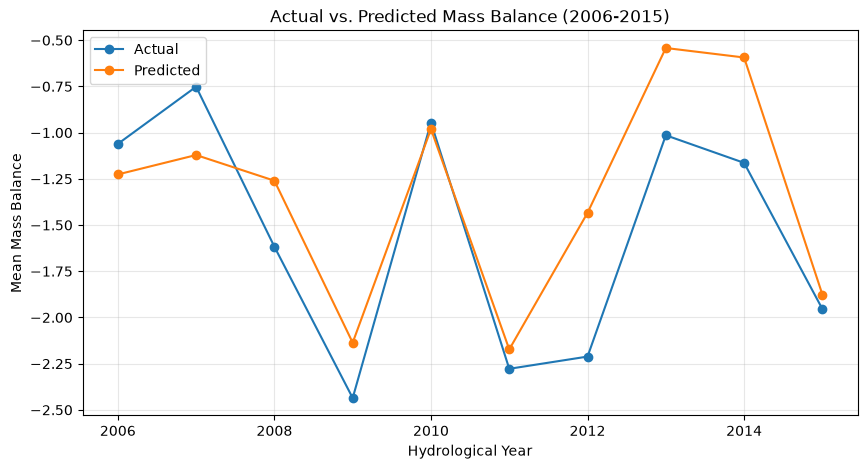

In [81]:
plt.figure(figsize=(10, 5))

plt.plot(
    yearly_errors.index,
    yearly_errors["actual_mass_balance"],
    marker="o",
    label="Actual"
)

plt.plot(
    yearly_errors.index,
    yearly_errors["predicted_mass_balance"],
    marker="o",
    label="Predicted"
)

plt.xlabel("Hydrological Year")
plt.ylabel("Mean Mass Balance")
plt.title("Actual vs. Predicted Mass Balance (2006-2015)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Actual vs. Predicted Results

The predicted values follow most of the same changes as the actual mass balance, but the size of the predictions is not always accurate. The largest difference can be seen around 2012 through 2014, where the model predicts less mass loss than what actually occurred. This shows that the model is picking up some of the overall pattern, but the four climate features do not explain all of the changes in glacier mass balance.

### Errors by Glacier

The errors are also checked by glacier to see if the model has more trouble predicting certain glacier records. If some glaciers consistently have larger errors, climate alone may not explain the differences between individual glaciers.

In [82]:
glacier_errors = (
    linear_results
    .groupby("glacier_index")
    .agg(
        MAE=("absolute_error", "mean"),
        mean_error=("error", "mean"),
        observations=("absolute_error", "count")
    )
    .sort_values("MAE", ascending=False)
)

glacier_errors.round(3).head(10)

,MAE,mean_error,observations
glacier_index,,,
527,0.869,-0.812,10
429,0.811,0.385,10
509,0.808,-0.692,10
526,0.764,-0.696,10
490,0.738,-0.738,10
489,0.617,-0.617,10
518,0.605,-0.499,10
535,0.594,-0.483,10
569,0.592,0.073,10


### Glacier Error Results

The model also performs differently between individual glacier records. The highest glacier-level MAE was 0.869 for glacier record 527, followed by 0.811 for record 429 and 0.808 for record 509. Several of the glacier records with the largest errors also have negative mean errors, meaning the model tends to predict less mass loss than what actually occurred for those records.

These differences suggest that the four climate features do not explain all of the variation between individual glaciers. Glacier specific characteristics such as elevation, area, or aspect could potentially explain some of the remaining error, but reliable record level topographic features were not available for the current dataset.

## Final Model Equation

The selected Linear Regression model was trained using standardized climate features. For interpretation, the fitted coefficients are converted back to the original temperature and precipitation units. This allows the final model equation to show how each seasonal climate variable contributes to the predicted glacier mass balance.

In [83]:
scaler = final_model.named_steps["standardscaler"]
regression = final_model.named_steps["linearregression"]

original_coefficients = regression.coef_ / scaler.scale_

original_intercept = (
    regression.intercept_
    - np.sum(regression.coef_ * scaler.mean_ / scaler.scale_)
)

coefficient_table = pd.DataFrame({
    "Feature": selected_features,
    "Coefficient": original_coefficients
})

print(f"Intercept: {original_intercept:.6f}")
display(coefficient_table.round(6))

Intercept: -0.778680


,Feature,Coefficient
0,winter_temperature_c,-0.044975
1,summer_temperature_c,-0.466786
2,winter_precipitation_mm,0.002054
3,summer_precipitation_mm,0.001979


### Final Linear Regression Equation

After converting the standardized coefficients back to the original climate units, the fitted Linear Regression model is

\[
\widehat{MB}
=
-0.778680
-0.044975(T_w)
-0.466786(T_s)
+0.002054(P_w)
+0.001979(P_s)
\]

where:

- \(T_w\) = winter temperature in °C
- \(T_s\) = summer temperature in °C
- \(P_w\) = winter precipitation in mm
- \(P_s\) = summer precipitation in mm
- \(\widehat{MB}\) = predicted annual glacier mass balance

The coefficients show that higher temperatures are associated with more negative mass balance, while higher precipitation is associated with more positive mass balance. Summer temperature has the largest temperature coefficient, showing a stronger relationship with mass balance than winter temperature in the fitted model.

This equation represents the final model trained on the 1968–2005 development period. The reserved 2006–2015 period was only used for the final evaluation.

## Final Model Summary

Linear Regression was selected as the final model because it had the strongest average performance during time-based cross validation. The model was then evaluated once on the reserved 2006–2015 test period and achieved an MAE of 0.473, RMSE of 0.570, and R² of 0.379.

The model captures some of the relationship between seasonal climate and glacier mass balance, but the error analysis shows that its accuracy varies between years and individual glaciers. In particular, the model sometimes underestimates the amount of mass loss during years with strongly negative mass balance.

The final model uses winter temperature, summer temperature, winter precipitation, and summer precipitation. These four features were kept after additional climate features were tested during feature selection and did not improve validation performance.

The next step is to prepare the historical and future climate inputs needed to use the final model for forecasting.